In [1]:
import kagglehub

# Download latest version
dataset_path = kagglehub.dataset_download("salmansajid05/oral-diseases")

print("Path to dataset files:", dataset_path)



Path to dataset files: /kaggle/input/datasets/salmansajid05/oral-diseases


In [2]:
!pip uninstall -y keras tensorflow
!pip install tensorflow==2.20.0 keras==3.12.3

Found existing installation: keras 3.12.3
Uninstalling keras-3.12.3:
  Successfully uninstalled keras-3.12.3
Found existing installation: tensorflow 2.20.0
Uninstalling tensorflow-2.20.0:
  Successfully uninstalled tensorflow-2.20.0
  Using cached tensorflow-2.20.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.5 kB)
  Using cached keras-3.12.3-py3-none-any.whl.metadata (5.9 kB)
Using cached tensorflow-2.20.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (620.7 MB)
Using cached keras-3.12.3-py3-none-any.whl (1.5 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
keras-hub 0.26.0 requires keras>=3.13, but you have keras 3.12.3 which is incompatible.


In [3]:
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sklearn
warnings.filterwarnings('ignore')

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import losses
from tensorflow.keras import layers
from tensorflow.keras import callbacks
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, ResNet50
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from sklearn.metrics import accuracy_score, f1_score


In [4]:
import sys

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow: 2.20.0
Keras: 3.12.3
NumPy: 2.0.2
Pandas: 2.3.3
Scikit-learn: 1.6.1


In [5]:
def explore_tree(root, max_depth=4):
  '''
  Finds the path of the images folder.
  '''
  for dirpath, dirnames, filenames in os.walk(root):
        depth = dirpath[len(root):].count(os.sep)
        if depth > max_depth:
            continue
        indent = '  ' * depth
        img_count = len([f for f in filenames if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"{indent}{os.path.basename(dirpath)}/  ({len(dirnames)} folders, {img_count} images)")

explore_tree(dataset_path)

oral-diseases/  (7 folders, 0 images)
  Data caries/  (1 folders, 0 images)
    Data caries/  (2 folders, 0 images)
      caries orignal data set/  (1 folders, 0 images)
        done/  (0 folders, 219 images)
      caries augmented data set/  (1 folders, 0 images)
        preview/  (0 folders, 2382 images)
  Mouth Ulcer/  (1 folders, 0 images)
    Mouth Ulcer/  (2 folders, 0 images)
      Mouth_Ulcer_augmented_DataSet/  (1 folders, 0 images)
        preview/  (0 folders, 2541 images)
      ulcer original dataset/  (1 folders, 0 images)
        ulcer original dataset/  (0 folders, 265 images)
  Tooth Discoloration/  (1 folders, 0 images)
    Tooth Discoloration /  (2 folders, 0 images)
      Tooth_discoloration_augmented_dataser/  (1 folders, 0 images)
        preview/  (0 folders, 1834 images)
      tooth discoloration original dataset/  (1 folders, 0 images)
        tooth discoloration original dataset/  (0 folders, 183 images)
  hypodontia/  (1 folders, 0 images)
    hypodontia/  (0 

In [6]:
root = dataset_path

# join path parts togther and remove leading/trailing whitespaces
def resolve_dir(*parts):
    """Join path parts but for each level match the folder name ignoring
    leading/trailing whitespace and case if an exact match isn't found."""
    current = root
    for part in parts:
        exact = os.path.join(current, part)
        if os.path.isdir(exact):
            current = exact
            continue
        target = part.strip().lower()
        match = None
        if os.path.isdir(current):
            for entry in os.listdir(current):
                if entry.strip().lower() == target:
                    match = entry
                    break
        current = os.path.join(current, match) if match else exact
    return current

# Some of the augmented lists are empty because there are no augmented photos for some of the classes
class_folders = {
    'Calculus': {
        'original': [resolve_dir('Calculus', 'Calculus')],
        'augmented': []
    },
    'Gingivitis': {
        'original': [resolve_dir('Gingivitis', 'Gingivitis')],
        'augmented': []
    },
    'Hypodontia': {
        'original': [resolve_dir('hypodontia', 'hypodontia')],
        'augmented': []
    },
    'Caries': {
        'original': [resolve_dir('Data caries', 'Data caries', 'caries orignal data set', 'done')],
        'augmented': [resolve_dir('Data caries', 'Data caries', 'caries augmented data set', 'preview')]
    },
    'Mouth_Ulcer': {
        'original': [resolve_dir('Mouth Ulcer', 'Mouth Ulcer', 'ulcer original dataset', 'ulcer original dataset')],
        'augmented': [resolve_dir('Mouth Ulcer', 'Mouth Ulcer', 'Mouth_Ulcer_augmented_DataSet', 'preview')]
    },
    'Tooth_Discoloration': {
        'original': [resolve_dir('Tooth Discoloration', 'Tooth Discoloration', 'tooth discoloration original dataset', 'tooth discoloration original dataset')],
        'augmented': [resolve_dir('Tooth Discoloration', 'Tooth Discoloration', 'Tooth_discoloration_augmented_dataser', 'preview')]
    },
}


def get_images(folder):
    '''
  Extract the images from the folder.
  '''
    if isinstance(folder, (list, tuple, set)):
        files = []
        for subfolder in folder:
            files.extend(get_images(subfolder))
        return sorted(set(files))

    files = set() # to return img without duplication
    for dirpath, _, filenames in os.walk(folder):
        for filename in filenames:
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                files.add(os.path.join(dirpath, filename))
    return sorted(files)

# A function for img counting usefull for data analysis later (summary table)
def count_images(folders):
    if isinstance(folders, (str, os.PathLike)):
        folders = [folders]

    count = 0
    for folder in folders:
        for dirpath, _, filenames in os.walk(folder):
            for filename in filenames:
                if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                    count += 1
    return count

# collect the data for summary tabel
rows = []
for cls, sources in class_folders.items():
    orig_count = count_images(sources['original'])
    aug_count  = count_images(sources['augmented'])
    rows.append({
        'Class': cls,
        'Original': orig_count,
        'Augmented': aug_count,
    })

# Check if some of the classes has 0 images (it means that the code was not able to extract the images from the folder)
missing = [r['Class'] for r in rows if r['Original'] == 0]
if missing:
    raise RuntimeError(
        f"These classes resolved to 0 original images, check class_folders paths: {missing}"
    )

df_counts = pd.DataFrame(rows).sort_values('Original', ascending=False).reset_index(drop=True)
max_count = df_counts['Original'].max()

df_counts

,Class,Original,Augmented
0,Gingivitis,2349,0
1,Calculus,1296,0
2,Hypodontia,1251,0
3,Mouth_Ulcer,265,2541
4,Caries,219,2382
5,Tooth_Discoloration,183,1834


The dataset includes pregenerated augmented image folders for three of the six classes (Caries, Mouth Ulcer, Tooth Discoloration) but not for the other three (Calculus, Gingivitis, Hypodontia) and using these folders as it is would introduce two problems: an inconsistent augmentation strategy across classes (each folder was generated with unknown potentially different transformation parameters) and a risk of data leakage since it isn't possible to trace which augmented image was derived from which original that means near-duplicate images could end up split across training and validation/test sets, which will make the validation accuracy better than it actually is. To avoid this all provided augmented image folders were dropped and only the original images were kept. A consistent controlled augmentation pipeline was then applied uniformly across all classes using Keras' ImageDataGenerator, applied only to the training split after the train/validation/test split was made ensuring no transformed version of a validation or test image ever appears in training.

In [7]:
# store the image path with its class to be able to convert it to dataframe
records = []
for cls, sources in class_folders.items():
    for path in get_images(sources['original']):  # originals only
        records.append({'filepath': path, 'class': cls})

df = pd.DataFrame(records)
print(df['class'].value_counts())

class
Gingivitis             2349
Calculus               1296
Hypodontia             1251
Mouth_Ulcer             265
Caries                  219
Tooth_Discoloration     183
Name: count, dtype: int64


In [8]:
# split the data to train, validation and test
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['class'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['class'], random_state=42
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 3894 | Val: 834 | Test: 835


In [9]:
# Start to generate augmented images

img_size = 224 # we need every image to have the same dimeensions
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)  # no augmentation just rescale

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='filepath', y_col='class',
    target_size=(img_size, img_size), batch_size=batch_size,
    class_mode='categorical', shuffle=True, color_mode='rgb'
)

# val_gen and test_gen only rescale (no augmentation) because I want validation/test performance to reflect real unmodified images

val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=val_df, x_col='filepath', y_col='class',
    target_size=(img_size, img_size), batch_size=batch_size,
    class_mode='categorical', shuffle=False, color_mode='rgb'
)

test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df, x_col='filepath', y_col='class',
    target_size=(img_size, img_size), batch_size=batch_size,
    class_mode='categorical', shuffle=False, color_mode='rgb'
)

Found 3894 validated image filenames belonging to 6 classes.
Found 834 validated image filenames belonging to 6 classes.
Found 835 validated image filenames belonging to 6 classes.


In [10]:
# To fix the imbalance in the dataset

class_names_sorted = np.unique(train_df['class'])  # alphabetical same order flow_from_dataframe uses internally if we don't use the same order our class weights could be assigned to the wrong disease

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=class_names_sorted,
    y=train_df['class']
)

# because Keras expects label: weights (both numbers) so we create pairs and put them in a dict
class_weight_dict = dict(zip(range(len(class_names_sorted)), class_weights))

# I don't want a large penalty on mistakes (1 mistake should not be given a lot of attention)
MAX_CLASS_WEIGHT = 4.0

# clipp every value apove 4
class_weight_dict_capped = {k: min(v, MAX_CLASS_WEIGHT) for k, v in class_weight_dict.items()}


print("Raw class weights:   ", {k: round(v, 2) for k, v in class_weight_dict.items()})
print("Capped class weights:", {k: round(v, 2) for k, v in class_weight_dict_capped.items()})


Raw class weights:    {0: np.float64(0.72), 1: np.float64(4.24), 2: np.float64(0.39), 3: np.float64(0.74), 4: np.float64(3.49), 5: np.float64(5.07)}
Capped class weights: {0: np.float64(0.72), 1: 4.0, 2: np.float64(0.39), 3: np.float64(0.74), 4: np.float64(3.49), 5: 4.0}


# **Custom CNN**

In [11]:
# Build a model
def build_model(num_classes, dropout_rate=0.5, dense_units=128):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), padding='same', input_shape=(img_size, img_size, 3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(256, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),

        layers.GlobalAveragePooling2D(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [12]:
build_model(6).save("test.keras")

I0000 00:00:1784314135.407247     269 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784314135.409437     269 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [13]:
num_classes = len(train_gen.class_indices)

# candidate values to try for each hyperparameter
search_space = {
    'learning_rate': [1e-3, 5e-4, 1e-4],
    'dropout_rate': [0.3, 0.5, 0.6],
    'dense_units': [64, 128, 256]
}

# starting values the model already used
best_params = {
    'learning_rate': 1e-3,
    'dropout_rate': 0.5,
    'dense_units': 128
}

SEARCH_EPOCHS = 6  # only for short experiments early stopping usually cuts this even shorter
search_results = []

for param_name, candidates in search_space.items():
    print(f"\n=== Tuning {param_name} (others fixed at {best_params}) ===")
    best_val_acc = -1 # to guarantee the first iteration always becomes the best temporarily
    best_value = best_params[param_name]

    for value in candidates:
        trial_params = best_params.copy() # to avoid modifying the original dictionary
        trial_params[param_name] = value

        # create a new CNN each iteration
        trial_model = build_model(
            num_classes,
            dropout_rate=trial_params['dropout_rate'],
            dense_units=trial_params['dense_units']
        )
        trial_model.compile(
            optimizer=Adam(learning_rate=trial_params['learning_rate']),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        early_stop = callbacks.EarlyStopping(
            monitor='val_loss', patience=2, restore_best_weights=True
        )

        # reset for each iteration to start reading the dataset from the beginning
        # it is important for each trial sees the data in the same way to make sure the comparison is fair
        train_gen.reset()
        val_gen.reset()

        history = trial_model.fit(
            train_gen,
            validation_data=val_gen,
            epochs=SEARCH_EPOCHS,
            class_weight=class_weight_dict,
            callbacks=[early_stop],
            verbose=0
        )

        val_acc = max(history.history['val_accuracy'])
        print(f"  {param_name} = {value!s:<8} -> best val_accuracy = {val_acc:.4f}")

        search_results.append({'param': param_name, 'value': value, 'val_accuracy': val_acc})

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_value = value

    best_params[param_name] = best_value
    print(f"--> Best {param_name}: {best_value}  (val_accuracy = {best_val_acc:.4f})")

print("\nFinal tuned hyperparameters:", best_params)



=== Tuning learning_rate (others fixed at {'learning_rate': 0.001, 'dropout_rate': 0.5, 'dense_units': 128}) ===


I0000 00:00:1784314148.710961     344 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  learning_rate = 0.001    -> best val_accuracy = 0.2722
  learning_rate = 0.0005   -> best val_accuracy = 0.0504
  learning_rate = 0.0001   -> best val_accuracy = 0.0504
--> Best learning_rate: 0.001  (val_accuracy = 0.2722)

=== Tuning dropout_rate (others fixed at {'learning_rate': 0.001, 'dropout_rate': 0.5, 'dense_units': 128}) ===
  dropout_rate = 0.3      -> best val_accuracy = 0.5180
  dropout_rate = 0.5      -> best val_accuracy = 0.1187
  dropout_rate = 0.6      -> best val_accuracy = 0.0635
--> Best dropout_rate: 0.3  (val_accuracy = 0.5180)

=== Tuning dense_units (others fixed at {'learning_rate': 0.001, 'dropout_rate': 0.3, 'dense_units': 128}) ===
  dense_units = 64       -> best val_accuracy = 0.4916
  dense_units = 128      -> best val_accuracy = 0.4400
  dense_units = 256      -> best val_accuracy = 0.1307
--> Best dense_units: 64  (val_accuracy = 0.4916)

Final tuned hyperparameters: {'learning_rate': 0.001, 'dropout_rate': 0.3, 'dense_units': 64}


In [14]:
results_df = pd.DataFrame(search_results)
results_df


,param,value,val_accuracy
0,learning_rate,0.0010,0.272182
1,learning_rate,0.0005,0.050360
2,learning_rate,0.0001,0.050360
3,dropout_rate,0.3000,0.517986
4,dropout_rate,0.5000,0.118705
5,dropout_rate,0.6000,0.063549
6,dense_units,64.0000,0.491607
7,dense_units,128.0000,0.440048
8,dense_units,256.0000,0.130695


In [15]:
# From the table above we could see what the best hyperparameters for the model so we save the best values
# best_params = {'learning_rate': 0.0001, 'dropout_rate': 0.5, 'dense_units': 256}

The final model built with the tuned hyperparameters found above (`best_params`) then trained for the full number of epochs.

In [16]:
num_classes = len(train_gen.class_indices)

model = build_model(
    num_classes,
    dropout_rate=best_params['dropout_rate'],
    dense_units=best_params['dense_units']
)
model.summary()


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_40 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_41 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_42 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_43 (Activation)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,174 (1.55 MB)

 Trainable params: 406,214 (1.55 MB)

 Non-trainable params: 960 (3.75 KB)

In [17]:
# compile the model using the tuned learning rate
model.compile(
    optimizer=Adam(learning_rate=best_params['learning_rate']),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [18]:
# train
EPOCHS = 40

# create folder for saving checkpoints
os.makedirs('checkpoints', exist_ok=True)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)
checkpoint = callbacks.ModelCheckpoint(
    'checkpoints/best_custom_cnn.keras', monitor='val_loss', save_best_only=True, verbose=1
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weight_dict_capped,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.2923 - loss: 1.7323
Epoch 1: val_loss improved from None to 3.07281, saving model to checkpoints/best_custom_cnn.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 68s 504ms/step - accuracy: 0.3369 - loss: 1.5542 - val_accuracy: 0.0480 - val_loss: 3.0728 - learning_rate: 0.0010
Epoch 2/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.4398 - loss: 1.3341
Epoch 2: val_loss did not improve from 3.07281
122/122 ━━━━━━━━━━━━━━━━━━━━ 57s 468ms/step - accuracy: 0.4443 - loss: 1.3435 - val_accuracy: 0.0480 - val_loss: 3.5030 - learning_rate: 0.0010
Epoch 3/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.4761 - loss: 1.2309
Epoch 3: val_loss did not improve from 3.07281
122/122 ━━━━━━━━━━━━━━━━━━━━ 57s 468ms/step - accuracy: 0.4664 - loss: 1.2442 - val_accuracy: 0.1223 - val_loss: 3.4016 - learning_rate: 0.0010
Epoch 4/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.4779 - loss: 1.2406
Epoch 4: val_loss impro

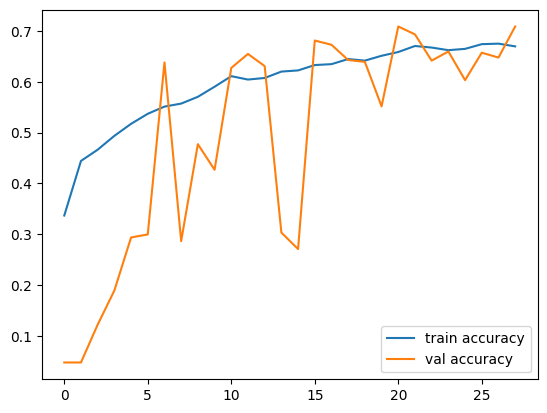

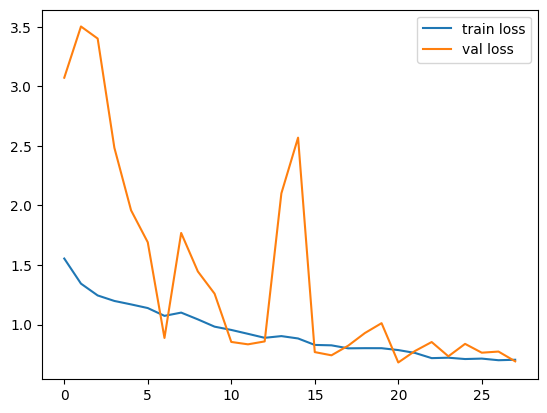

In [19]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()

In [20]:
val_loss, val_acc = model.evaluate(val_gen)
print("Validation Accuracy:", val_acc)


27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.7086 - loss: 0.6814
Validation Accuracy: 0.7086330652236938


In [21]:
test_loss, test_acc = model.evaluate(test_gen)
print("Test Accuracy (Custom CNN):", test_acc)

27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 306ms/step - accuracy: 0.6778 - loss: 0.7083
Test Accuracy (Custom CNN): 0.6778442859649658


In [22]:
model.save('oral_diseases_model.h5')
model.save_weights('oral_diseases_weights.weights.h5')
model.save('oral_diseases_model.keras')

27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step


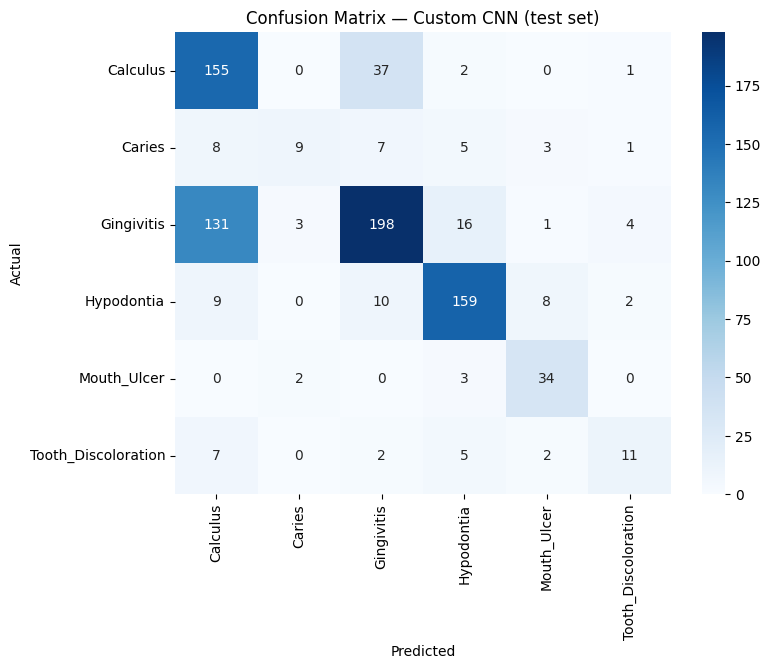

In [23]:
# confusion matrix for Custom CNN

test_gen.reset()  # make sure we start from batch 0 so order lines up with .classes

y_pred_probs = model.predict(test_gen)
y_pred_custom = np.argmax(y_pred_probs, axis=1)      # softmax probabilities -> predicted class index
y_true_custom = test_gen.classes                     # true class index for every row in generator order (shuffle=False)

class_labels = list(test_gen.class_indices.keys())

cm_custom = confusion_matrix(y_true_custom, y_pred_custom)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Custom CNN (test set)')
plt.show()

In [24]:
# classification report (Custom CNN)
print(classification_report(y_true_custom, y_pred_custom, target_names=class_labels))

custom_test_acc = accuracy_score(y_true_custom, y_pred_custom)
custom_f1_macro = f1_score(y_true_custom, y_pred_custom, average='macro')

                     precision    recall  f1-score   support

           Calculus       0.50      0.79      0.61       195
             Caries       0.64      0.27      0.38        33
         Gingivitis       0.78      0.56      0.65       353
         Hypodontia       0.84      0.85      0.84       188
        Mouth_Ulcer       0.71      0.87      0.78        39
Tooth_Discoloration       0.58      0.41      0.48        27

           accuracy                           0.68       835
          macro avg       0.67      0.63      0.63       835
       weighted avg       0.71      0.68      0.68       835



# **Pre-trained models**

Both pretrained Model has the ImageNet-trained
convolutional base frozen (`base_model.trainable = False`) and only a small classifier
head is trained on top This keeps the comparison fair (similar training budget/epochs to
the custom CNN)

And then we will fine-tune (unfreezing some top layers of the base and training with a very
small learning rate)

EfficientNetB0 and ResNet50 each expect their **own** input
preprocessing (not as we used for the custom CNN `rescale=1./255`) so we build a
new set of generators per model using that model's `preprocess_input` function.

In [25]:
def make_generators(preprocess_func, img_size=224, batch_size=32):
    '''
  Prepare the datasets and create train validation and test generators for the pretrained models.
  '''
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_func,
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.15,
        horizontal_flip=True,
        brightness_range=[0.8, 1.2],
        fill_mode='nearest'
    )
    val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_func)

    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_df, x_col='filepath', y_col='class',
        target_size=(img_size, img_size), batch_size=batch_size,
        class_mode='categorical', shuffle=True, color_mode='rgb'
    )
    val_gen = val_test_datagen.flow_from_dataframe(
        dataframe=val_df, x_col='filepath', y_col='class',
        target_size=(img_size, img_size), batch_size=batch_size,
        class_mode='categorical', shuffle=False, color_mode='rgb'
    )
    test_gen = val_test_datagen.flow_from_dataframe(
        dataframe=test_df, x_col='filepath', y_col='class',
        target_size=(img_size, img_size), batch_size=batch_size,
        class_mode='categorical', shuffle=False, color_mode='rgb'
    )
    return train_gen, val_gen, test_gen


def build_transfer_model(base_model_class, num_classes, dense_units=256, dropout_rate=0.5):
  # include_top=False --> removes the original ImageNet classifier we just keep the feature extractor
    base_model = base_model_class(
        include_top=False, weights='imagenet', input_shape=(img_size, img_size, 3)
    )
    base_model.trainable = False  # freeze pretrained weights feature extraction only

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(dense_units, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model, base_model


def evaluate_and_report(model, test_gen, class_labels, model_name):
    test_gen.reset()
    test_loss, test_acc = model.evaluate(test_gen)
    print(f"Test Accuracy ({model_name}):", test_acc)

    test_gen.reset()
    y_pred_probs = model.predict(test_gen)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_gen.classes # retrives the actual class labels

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix — {model_name} (test set)')
    plt.show()

    print(classification_report(y_true, y_pred, target_names=class_labels))

    f1_macro = f1_score(y_true, y_pred, average='macro')
    return test_acc, f1_macro

## EfficientNetB0

In [26]:
train_gen_eff, val_gen_eff, test_gen_eff = make_generators(effnet_preprocess)

num_classes = len(train_gen_eff.class_indices)
class_labels = list(train_gen_eff.class_indices.keys())

effnet_model, effnet_base = build_transfer_model(EfficientNetB0, num_classes)

effnet_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

effnet_model.summary()

Found 3894 validated image filenames belonging to 6 classes.
Found 834 validated image filenames belonging to 6 classes.
Found 835 validated image filenames belonging to 6 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,380,073 (16.71 MB)

 Trainable params: 329,990 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

In [27]:
EPOCHS = 25

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True
)

effnet_history = effnet_model.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/25


2026-07-17 19:55:43.743723: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-17 19:55:43.887912: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-17 19:55:44.256619: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-17 19:55:44.398840: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-17 19:55:45.213922: E external/local_xla/xla/stream_

 28/122 ━━━━━━━━━━━━━━━━━━━━ 38s 414ms/step - accuracy: 0.3330 - loss: 2.3526

2026-07-17 19:56:11.210155: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-17 19:56:11.351963: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-17 19:56:11.695822: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-17 19:56:11.838524: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-17 19:56:11.979872: E external/local_xla/xla/stream_

122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.4348 - loss: 1.7671

2026-07-17 19:57:12.656587: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-17 19:57:12.791382: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-17 19:57:13.106657: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-17 19:57:13.248136: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-17 19:57:14.008269: E external/local_xla/xla/stream_

122/122 ━━━━━━━━━━━━━━━━━━━━ 113s 709ms/step - accuracy: 0.5144 - loss: 1.3872 - val_accuracy: 0.6511 - val_loss: 0.8709
Epoch 2/25
122/122 ━━━━━━━━━━━━━━━━━━━━ 55s 452ms/step - accuracy: 0.6240 - loss: 0.8651 - val_accuracy: 0.6894 - val_loss: 0.7833
Epoch 3/25
122/122 ━━━━━━━━━━━━━━━━━━━━ 56s 457ms/step - accuracy: 0.6697 - loss: 0.7188 - val_accuracy: 0.7110 - val_loss: 0.7486
Epoch 4/25
122/122 ━━━━━━━━━━━━━━━━━━━━ 55s 448ms/step - accuracy: 0.6926 - loss: 0.6172 - val_accuracy: 0.7158 - val_loss: 0.6985
Epoch 5/25
122/122 ━━━━━━━━━━━━━━━━━━━━ 55s 451ms/step - accuracy: 0.7175 - loss: 0.5915 - val_accuracy: 0.7242 - val_loss: 0.6679
Epoch 6/25
122/122 ━━━━━━━━━━━━━━━━━━━━ 55s 450ms/step - accuracy: 0.7242 - loss: 0.5687 - val_accuracy: 0.7302 - val_loss: 0.6263
Epoch 7/25
122/122 ━━━━━━━━━━━━━━━━━━━━ 56s 455ms/step - accuracy: 0.7465 - loss: 0.5185 - val_accuracy: 0.7506 - val_loss: 0.6362
Epoch 8/25
122/122 ━━━━━━━━━━━━━━━━━━━━ 55s 451ms/step - accuracy: 0.7401 - loss: 0.4894 - va

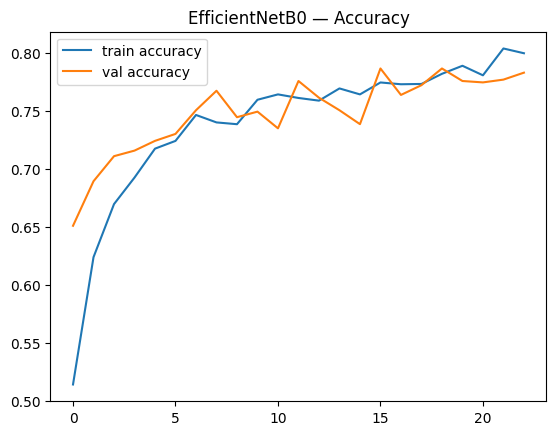

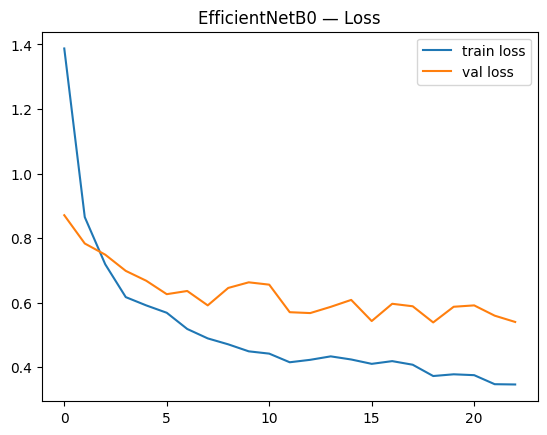

In [28]:
plt.plot(effnet_history.history['accuracy'], label='train accuracy')
plt.plot(effnet_history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title('EfficientNetB0 — Accuracy')
plt.show()

plt.plot(effnet_history.history['loss'], label='train loss')
plt.plot(effnet_history.history['val_loss'], label='val loss')
plt.legend()
plt.title('EfficientNetB0 — Loss')
plt.show()

26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.7868 - loss: 0.5375

2026-07-17 20:17:22.853085: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-17 20:17:22.988326: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-17 20:17:23.300231: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-17 20:17:23.442358: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-17 20:17:24.196138: E external/local_xla/xla/stream_

27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 476ms/step - accuracy: 0.7916 - loss: 0.5272
Test Accuracy (EfficientNetB0): 0.7916167378425598
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 333ms/step


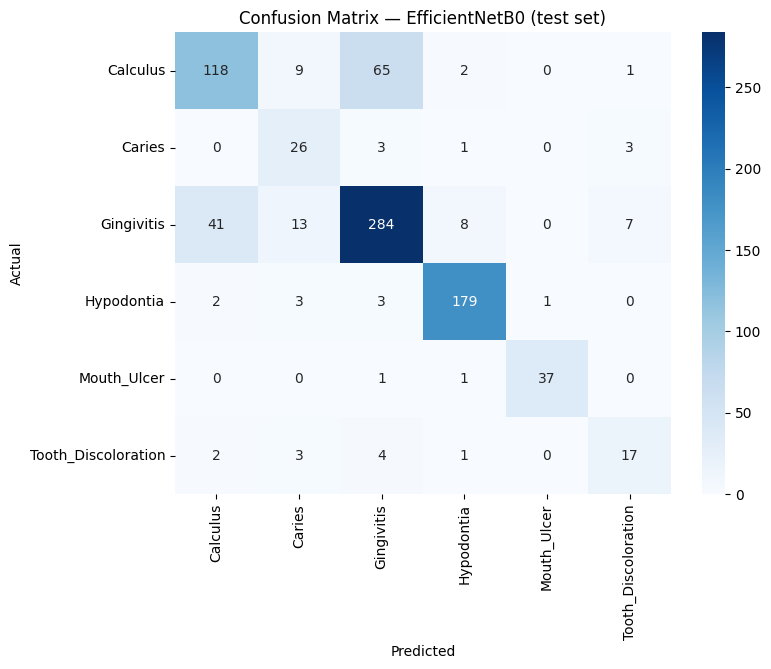

                     precision    recall  f1-score   support

           Calculus       0.72      0.61      0.66       195
             Caries       0.48      0.79      0.60        33
         Gingivitis       0.79      0.80      0.80       353
         Hypodontia       0.93      0.95      0.94       188
        Mouth_Ulcer       0.97      0.95      0.96        39
Tooth_Discoloration       0.61      0.63      0.62        27

           accuracy                           0.79       835
          macro avg       0.75      0.79      0.76       835
       weighted avg       0.80      0.79      0.79       835



In [29]:
effnet_test_acc, effnet_f1_macro = evaluate_and_report(
    effnet_model, test_gen_eff, class_labels, "EfficientNetB0"
)

### EfficientNetB0 fine-tuning

Above only trained the small head Now we unfreeze the top portion of
the backbone and continue training with a much smaller learning rate so the
high-level filters can adapt to oral-disease images instead of staying stuck on
generic ImageNet features.

In [30]:
effnet_base.trainable = True

FINE_TUNE_AT = len(effnet_base.layers) - 40  # unfreeze roughly the last 30 layers

# after taking the 30 last layers freeze again
for layer in effnet_base.layers[:FINE_TUNE_AT]:
    layer.trainable = False

for layer in effnet_base.layers[FINE_TUNE_AT:]:
  # don't touch the BatchNormalization layer even in the 30 unfrozen layers
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

effnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),  # small LR we don't want to destroy pretrained weights
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

effnet_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,380,073 (16.71 MB)

 Trainable params: 2,367,510 (9.03 MB)

 Non-trainable params: 2,012,563 (7.68 MB)

In [31]:
early_stop_ft = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

reduce_lr_ft = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)

checkpoint_ft = callbacks.ModelCheckpoint(
    'checkpoints/best_effnet_finetuned.keras', monitor='val_loss', save_best_only=True, verbose=1
)

effnet_finetune_history = effnet_model.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=30,
    class_weight=class_weight_dict_capped,
    callbacks=[early_stop_ft, reduce_lr_ft, checkpoint_ft]
)

Epoch 1/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.7918 - loss: 0.3201
Epoch 1: val_loss improved from None to 0.52033, saving model to checkpoints/best_effnet_finetuned.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 101s 627ms/step - accuracy: 0.7902 - loss: 0.3221 - val_accuracy: 0.7854 - val_loss: 0.5203 - learning_rate: 1.0000e-05
Epoch 2/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.8000 - loss: 0.3138
Epoch 2: val_loss improved from 0.52033 to 0.51840, saving model to checkpoints/best_effnet_finetuned.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 54s 444ms/step - accuracy: 0.7956 - loss: 0.3270 - val_accuracy: 0.7842 - val_loss: 0.5184 - learning_rate: 1.0000e-05
Epoch 3/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.8165 - loss: 0.3129
Epoch 3: val_loss improved from 0.51840 to 0.51113, saving model to checkpoints/best_effnet_finetuned.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 55s 453ms/step - accuracy: 0.8136 - loss: 0.3069 - val_accuracy: 0.7902 - val_loss: 0.511

27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 276ms/step - accuracy: 0.8072 - loss: 0.4621
Test Accuracy (EfficientNetB0 (fine-tuned)): 0.8071856498718262
27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 361ms/step


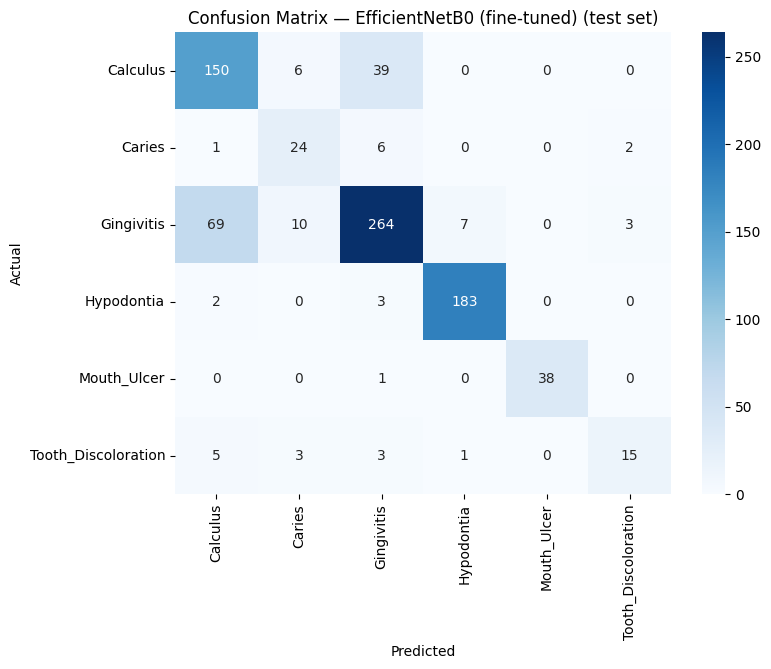

                     precision    recall  f1-score   support

           Calculus       0.66      0.77      0.71       195
             Caries       0.56      0.73      0.63        33
         Gingivitis       0.84      0.75      0.79       353
         Hypodontia       0.96      0.97      0.97       188
        Mouth_Ulcer       1.00      0.97      0.99        39
Tooth_Discoloration       0.75      0.56      0.64        27

           accuracy                           0.81       835
          macro avg       0.79      0.79      0.79       835
       weighted avg       0.82      0.81      0.81       835



In [32]:
effnet_ft_test_acc, effnet_ft_f1_macro = evaluate_and_report(
    effnet_model, test_gen_eff, class_labels, "EfficientNetB0 (fine-tuned)"
)

## ResNet50

In [33]:
train_gen_res, val_gen_res, test_gen_res = make_generators(resnet_preprocess)

resnet_model, resnet_base = build_transfer_model(ResNet50, num_classes)

resnet_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

Found 3894 validated image filenames belonging to 6 classes.
Found 834 validated image filenames belonging to 6 classes.
Found 835 validated image filenames belonging to 6 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_12     │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,822 (91.99 MB)

 Trainable params: 526,598 (2.01 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

In [34]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True
)

resnet_history = resnet_model.fit(
    train_gen_res,
    validation_data=val_gen_res,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/25
122/122 ━━━━━━━━━━━━━━━━━━━━ 89s 612ms/step - accuracy: 0.5421 - loss: 1.2129 - val_accuracy: 0.7182 - val_loss: 0.7278
Epoch 2/25
122/122 ━━━━━━━━━━━━━━━━━━━━ 60s 488ms/step - accuracy: 0.6574 - loss: 0.7935 - val_accuracy: 0.7398 - val_loss: 0.6769
Epoch 3/25
122/122 ━━━━━━━━━━━━━━━━━━━━ 61s 497ms/step - accuracy: 0.6931 - loss: 0.6374 - val_accuracy: 0.7038 - val_loss: 0.7489
Epoch 4/25
122/122 ━━━━━━━━━━━━━━━━━━━━ 59s 483ms/step - accuracy: 0.7152 - loss: 0.6083 - val_accuracy: 0.7422 - val_loss: 0.6799
Epoch 5/25
122/122 ━━━━━━━━━━━━━━━━━━━━ 60s 488ms/step - accuracy: 0.7355 - loss: 0.5391 - val_accuracy: 0.7458 - val_loss: 0.6428
Epoch 6/25
122/122 ━━━━━━━━━━━━━━━━━━━━ 61s 500ms/step - accuracy: 0.7452 - loss: 0.4964 - val_accuracy: 0.7698 - val_loss: 0.5481
Epoch 7/25
122/122 ━━━━━━━━━━━━━━━━━━━━ 61s 500ms/step - accuracy: 0.7504 - loss: 0.4703 - val_accuracy: 0.7698 - val_loss: 0.5613
Epoch 8/25
122/122 ━━━━━━━━━━━━━━━━━━━━ 61s 497ms/step - accuracy: 0.7609 - loss: 0

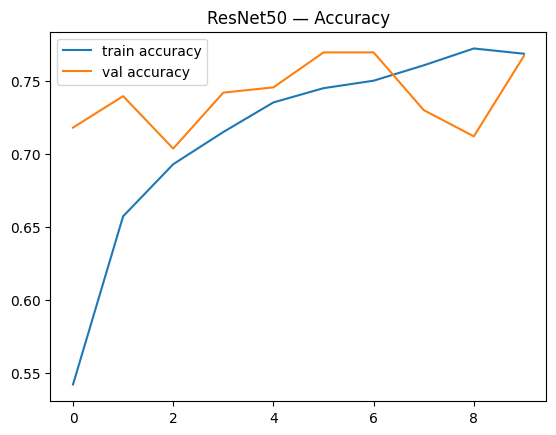

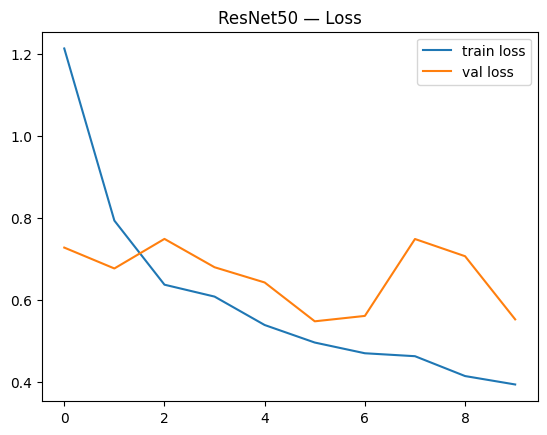

In [35]:
plt.plot(resnet_history.history['accuracy'], label='train accuracy')
plt.plot(resnet_history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title('ResNet50 — Accuracy')
plt.show()

plt.plot(resnet_history.history['loss'], label='train loss')
plt.plot(resnet_history.history['val_loss'], label='val loss')
plt.legend()
plt.title('ResNet50 — Loss')
plt.show()

27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 230ms/step - accuracy: 0.7868 - loss: 0.5420
Test Accuracy (ResNet50): 0.7868263721466064
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 266ms/step


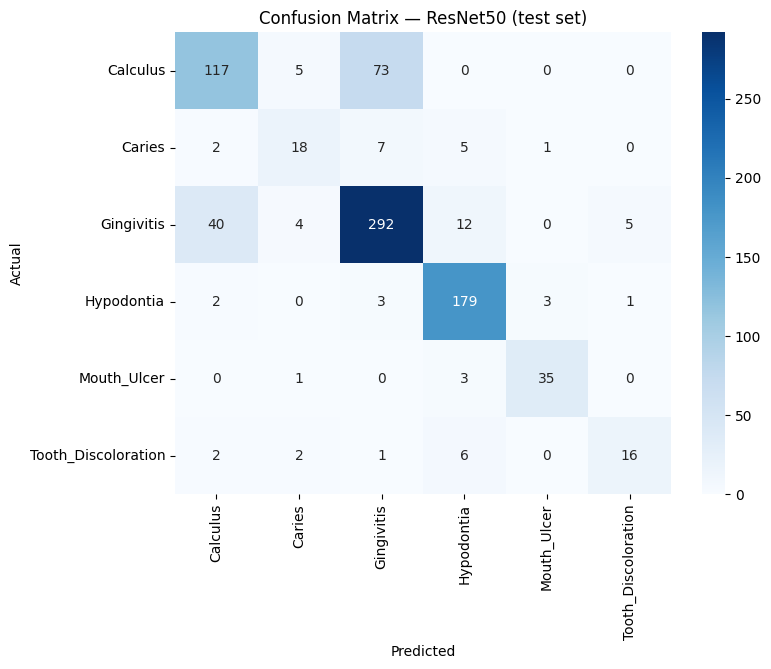

                     precision    recall  f1-score   support

           Calculus       0.72      0.60      0.65       195
             Caries       0.60      0.55      0.57        33
         Gingivitis       0.78      0.83      0.80       353
         Hypodontia       0.87      0.95      0.91       188
        Mouth_Ulcer       0.90      0.90      0.90        39
Tooth_Discoloration       0.73      0.59      0.65        27

           accuracy                           0.79       835
          macro avg       0.77      0.74      0.75       835
       weighted avg       0.78      0.79      0.78       835



In [36]:
resnet_test_acc, resnet_f1_macro = evaluate_and_report(
    resnet_model, test_gen_res, class_labels, "ResNet50"
)

### ResNet50 fine-tuning

unfreeze the top of the ResNet50 backbone and keep training at a low
learning rate so it can specialize on this dataset instead of staying generic.

In [37]:
resnet_base.trainable = True

FINE_TUNE_AT = len(resnet_base.layers) - 40
for layer in resnet_base.layers[:FINE_TUNE_AT]:
    layer.trainable = False

for layer in resnet_base.layers[FINE_TUNE_AT:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_12     │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,822 (91.99 MB)

 Trainable params: 16,333,318 (62.31 MB)

 Non-trainable params: 7,781,504 (29.68 MB)

In [38]:
early_stop_ft = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr_ft = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
checkpoint_ft = callbacks.ModelCheckpoint(
    'checkpoints/best_resnet_finetuned.keras', monitor='val_loss', save_best_only=True, verbose=1
)

resnet_finetune_history = resnet_model.fit(
    train_gen_res,
    validation_data=val_gen_res,
    epochs=30,
    class_weight=class_weight_dict_capped,
    callbacks=[early_stop_ft, reduce_lr_ft, checkpoint_ft]
)


Epoch 1/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.7734 - loss: 0.4217
Epoch 1: val_loss improved from None to 0.56096, saving model to checkpoints/best_resnet_finetuned.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 93s 618ms/step - accuracy: 0.7655 - loss: 0.4320 - val_accuracy: 0.7722 - val_loss: 0.5610 - learning_rate: 1.0000e-05
Epoch 2/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.7949 - loss: 0.3296
Epoch 2: val_loss improved from 0.56096 to 0.53374, saving model to checkpoints/best_resnet_finetuned.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 63s 512ms/step - accuracy: 0.7912 - loss: 0.3329 - val_accuracy: 0.7962 - val_loss: 0.5337 - learning_rate: 1.0000e-05
Epoch 3/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.8022 - loss: 0.2933
Epoch 3: val_loss did not improve from 0.53374
122/122 ━━━━━━━━━━━━━━━━━━━━ 62s 508ms/step - accuracy: 0.7997 - loss: 0.3152 - val_accuracy: 0.7806 - val_loss: 0.5811 - learning_rate: 1.0000e-05
Epoch 4/30
122/122 ━━━━━━━━━━━━━

27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 207ms/step - accuracy: 0.8275 - loss: 0.4349
Test Accuracy (ResNet50 (fine-tuned)): 0.8275449275970459
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 254ms/step


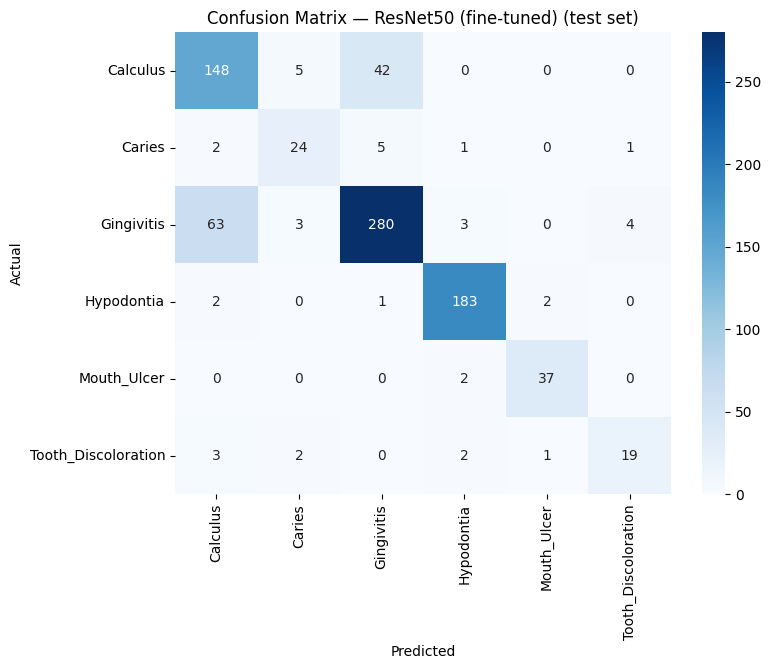

                     precision    recall  f1-score   support

           Calculus       0.68      0.76      0.72       195
             Caries       0.71      0.73      0.72        33
         Gingivitis       0.85      0.79      0.82       353
         Hypodontia       0.96      0.97      0.97       188
        Mouth_Ulcer       0.93      0.95      0.94        39
Tooth_Discoloration       0.79      0.70      0.75        27

           accuracy                           0.83       835
          macro avg       0.82      0.82      0.82       835
       weighted avg       0.83      0.83      0.83       835



In [39]:
resnet_ft_test_acc, resnet_ft_f1_macro = evaluate_and_report(
    resnet_model, test_gen_res, class_labels, "ResNet50 (fine-tuned)"
)

## Model comparison

In [40]:
test_gen_eff.reset()
_, effnet_ft_test_acc = effnet_model.evaluate(test_gen_eff)
print("Test Accuracy (EfficientNetB0 fine-tuned):", effnet_ft_test_acc)

test_gen_eff.reset()
y_pred_probs = effnet_model.predict(test_gen_eff)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen_eff.classes
effnet_ft_f1_macro = f1_score(y_true, y_pred, average='macro')
print("Macro F1 (EfficientNetB0 fine-tuned):", effnet_ft_f1_macro)

27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.8072 - loss: 0.4621
Test Accuracy (EfficientNetB0 fine-tuned): 0.8071856498718262
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step
Macro F1 (EfficientNetB0 fine-tuned): 0.7871211928766982


In [41]:
comparison_df = pd.DataFrame({
    'Model': ['Custom CNN', 'EfficientNetB0 (frozen)', 'EfficientNetB0 (fine-tuned)',
              'ResNet50 (frozen)', 'ResNet50 (fine-tuned)'],
    'Test Accuracy': [custom_test_acc, effnet_test_acc, effnet_ft_test_acc,
                       resnet_test_acc, resnet_ft_test_acc],
    'Macro F1': [custom_f1_macro, effnet_f1_macro, effnet_ft_f1_macro,
                 resnet_f1_macro, resnet_ft_f1_macro]
})
comparison_df

,Model,Test Accuracy,Macro F1
0,Custom CNN,0.677844,0.625061
1,EfficientNetB0 (frozen),0.791617,0.762480
2,EfficientNetB0 (fine-tuned),0.807186,0.787121
3,ResNet50 (frozen),0.786826,0.747933
4,ResNet50 (fine-tuned),0.827545,0.817159


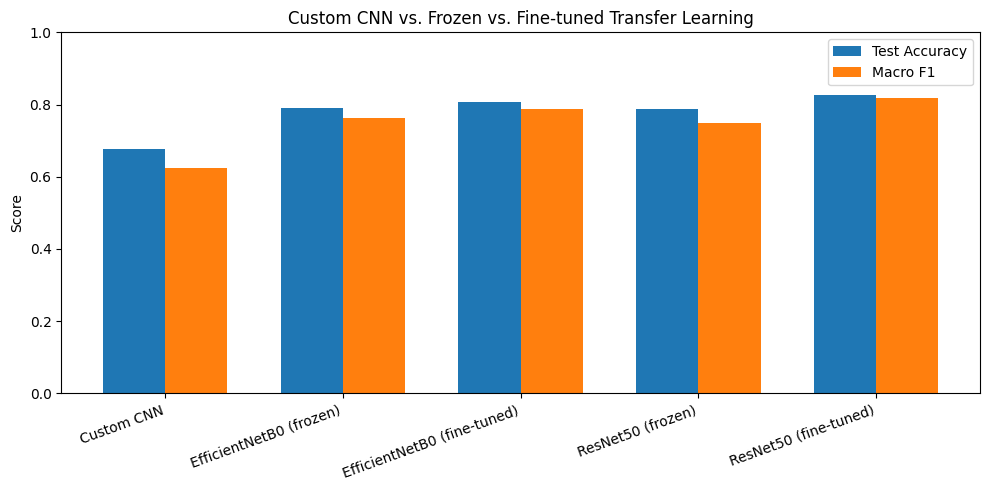

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['Test Accuracy'], width, label='Test Accuracy')
ax.bar(x + width/2, comparison_df['Macro F1'], width, label='Macro F1')

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=20, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Custom CNN vs. Frozen vs. Fine-tuned Transfer Learning')
ax.legend()
plt.tight_layout()
plt.show()

In [43]:
# Save the models and their metadata for the streamlit app

import json, shutil

# Create a new file
SAVE_DIR = 'saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

# copy the best checkpoint (the best-performing model)
checkpoint_map = {
    'custom_cnn.keras':          'checkpoints/best_custom_cnn.keras',
    'efficientnetb0.keras':      'checkpoints/best_effnet_finetuned.keras',
    'resnet50.keras':            'checkpoints/best_resnet_finetuned.keras',
}
for dest_name, ckpt_path in checkpoint_map.items():
    dest = os.path.join(SAVE_DIR, dest_name)
    if os.path.exists(ckpt_path):
        shutil.copy(ckpt_path, dest)
    else:
        # as fallback if checkpoint wasn't produced save whatever is currently in memory instead
        {'custom_cnn.keras': model,
         'efficientnetb0.keras': effnet_model,
         'resnet50.keras': resnet_model}[dest_name].save(dest)

# must save the mapping between labels and their indices
class_indices = train_gen.class_indices
# save the reversed mapping
idx_to_class = {v: k for k, v in class_indices.items()}
with open(os.path.join(SAVE_DIR, 'class_indices.json'), 'w') as f:
    json.dump({'class_to_idx': class_indices, 'idx_to_class': idx_to_class}, f, indent=2)

# save everything about the models
metadata = {
    'img_size': img_size,
    'models': {
        'custom_cnn': {
            'file': 'custom_cnn.keras',
            'preprocessing': 'rescale_1_255',
            'test_accuracy': float(custom_test_acc),
            'macro_f1': float(custom_f1_macro),
        },
        'efficientnetb0': {
            'file': 'efficientnetb0.keras',
            'preprocessing': 'efficientnet',
            'test_accuracy': float(effnet_ft_test_acc),
            'macro_f1': float(effnet_ft_f1_macro),
        },
        'resnet50': {
            'file': 'resnet50.keras',
            'preprocessing': 'resnet50',
            'test_accuracy': float(resnet_ft_test_acc),
            'macro_f1': float(resnet_ft_f1_macro),
        },
    }
}
with open(os.path.join(SAVE_DIR, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

# 4) Full comparison table for the user interface
comparison_df.to_csv(os.path.join(SAVE_DIR, 'comparison_metrics.csv'), index=False)

print("Saved to", SAVE_DIR, ":", os.listdir(SAVE_DIR))


Saved to saved_models : ['class_indices.json', 'efficientnetb0.keras', 'custom_cnn.keras', 'metadata.json', 'comparison_metrics.csv', 'resnet50.keras']


In [44]:
# saves a snapshot of your current Python environment (using it for streamlit later)
!pip freeze > requirements.txt